# Authors

This notebook lists authors and the number of records they contributed to our database

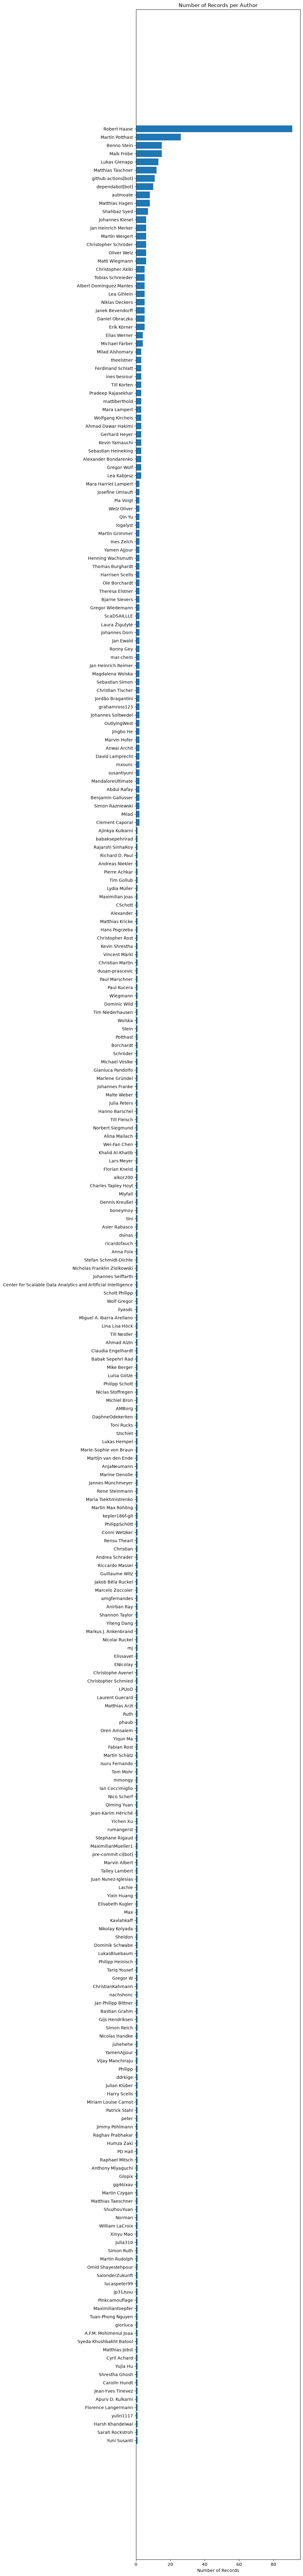

In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

with open("../resources/scadsai.yml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

author_counter = Counter()
for entry in data["resources"]:
    authors = entry.get("authors", [])
    for author in authors:
        author_counter[author] += 1

df_authors = pd.DataFrame(author_counter.items(), columns=["author", "count"])
df_authors = df_authors.sort_values("count", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(df_authors) * 0.3)))
ax.barh(df_authors["author"][::-1], df_authors["count"][::-1])
ax.set_xlabel("Number of Records")
ax.set_title("Number of Records per Author")
plt.tight_layout()
plt.show()